In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════════════════════

import os, shutil, pickle
import numpy as np
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt
from datetime import datetime

import extract_features
import dutch_30_feature_extractor
import dutch_30_pipeline
import acoustic_change_detector
import run_pipeline

from extract_features import extractHG as _orig_extractHG
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from dataset_config import Dutch30Config
from run_pipeline import DEFAULT_RUN_CONFIG, run_path_b, _run_crf_experiment

ARCHIVE_DIR = 'archive'
os.makedirs(ARCHIVE_DIR, exist_ok=True)

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Helper: standard HG amplitude (the production baseline)
# ═══════════════════════════════════════════════════════════════════════════════

def _hg_amplitude(detrended, sr, smoothing_hz=10.0):
    """Production high-gamma envelope (pwr_lpf_10)."""
    sos_hg = scipy.signal.iirfilter(4, [70/(sr/2), 170/(sr/2)],
                                    btype='bandpass', output='sos')
    hg = scipy.signal.sosfiltfilt(sos_hg, detrended, axis=0)
    for f_notch in (100.0, 150.0):
        sos_n = scipy.signal.iirfilter(4, [(f_notch-2)/(sr/2), (f_notch+2)/(sr/2)],
                                       btype='bandstop', output='sos')
        hg = scipy.signal.sosfiltfilt(sos_n, hg, axis=0)
    pwr = hg ** 2
    sos_lp = scipy.signal.iirfilter(4, smoothing_hz/(sr/2),
                                    btype='lowpass', output='sos')
    return np.abs(scipy.signal.sosfiltfilt(sos_lp, pwr, axis=0)), hg


def _bandpass_phase(detrended, sr, low, high):
    """Bandpass + Hilbert → instantaneous phase."""
    sos = scipy.signal.iirfilter(4, [low/(sr/2), high/(sr/2)],
                                 btype='bandpass', output='sos')
    bp = scipy.signal.sosfiltfilt(sos, detrended, axis=0)
    analytic = scipy.signal.hilbert(
        bp, scipy.fftpack.next_fast_len(bp.shape[0]), axis=0
    )[:bp.shape[0]]
    return np.angle(analytic), np.abs(analytic)


def _window_avg(arr, sr, windowLength, frameshift):
    """Window-average across time, returning (n_windows, n_channels)."""
    n_win = int(np.floor((arr.shape[0] - windowLength*sr) / (frameshift*sr)))
    out = np.zeros((n_win, arr.shape[1]))
    for w in range(n_win):
        s = int(np.floor(w * frameshift * sr))
        e = int(np.floor(s + windowLength * sr))
        out[w, :] = arr[s:e, :].mean(axis=0)
    return out

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Six variant extractHG functions
# ═══════════════════════════════════════════════════════════════════════════════

def make_phase_variant(band_low, band_high, name):
    """Variant 1-3: per-frame cos+sin of phase at given band, concatenated to HG."""
    def _fn(data, sr, windowLength=0.015, frameshift=0.005, debug=False):
        d = scipy.signal.detrend(data, axis=0)
        smoothed, _ = _hg_amplitude(d, sr)
        phase, _ = _bandpass_phase(d, sr, band_low, band_high)
        cos_p, sin_p = np.cos(phase), np.sin(phase)
        feat_hg  = np.sqrt(_window_avg(smoothed, sr, windowLength, frameshift))
        feat_cos = _window_avg(cos_p,    sr, windowLength, frameshift)
        feat_sin = _window_avg(sin_p,    sr, windowLength, frameshift)
        return np.concatenate([feat_hg, feat_cos, feat_sin], axis=1)
    _fn.__name__ = f'extractHG_with_{name}_perframe'
    return _fn


def extractHG_compact_theta(data, sr, windowLength=0.015, frameshift=0.005,
                            debug=False):
    """Variant 4: COMPACT theta phase — long-window-smoothed (100 ms moving-average
    of cos/sin) so phase estimate is more stable. Feature dim: HG + cos + sin = 3×.
    But the slower phase is more reliably estimated, so less noise per frame."""
    d = scipy.signal.detrend(data, axis=0)
    smoothed, _ = _hg_amplitude(d, sr)
    phase, _ = _bandpass_phase(d, sr, 4, 8)

    # Smooth cos/sin with a 100 ms moving average BEFORE windowing
    smooth_n = int(0.1 * sr)
    kernel = np.ones(smooth_n) / smooth_n
    cos_p = np.array([np.convolve(np.cos(phase[:, c]), kernel, mode='same')
                      for c in range(phase.shape[1])]).T
    sin_p = np.array([np.convolve(np.sin(phase[:, c]), kernel, mode='same')
                      for c in range(phase.shape[1])]).T

    feat_hg  = np.sqrt(_window_avg(smoothed, sr, windowLength, frameshift))
    feat_cos = _window_avg(cos_p,    sr, windowLength, frameshift)
    feat_sin = _window_avg(sin_p,    sr, windowLength, frameshift)
    return np.concatenate([feat_hg, feat_cos, feat_sin], axis=1)


def extractHG_phase_coherence(data, sr, windowLength=0.015, frameshift=0.005,
                              debug=False):
    """Variant 5: Phase coherence — measure how synchronized each channel's
    theta phase is with the cross-channel mean. Adds 1 feature per channel
    (NOT 2). Captures 'is this channel locked to the global rhythm right now'."""
    d = scipy.signal.detrend(data, axis=0)
    smoothed, _ = _hg_amplitude(d, sr)
    phase, _ = _bandpass_phase(d, sr, 4, 8)

    # Phase-locking value: cos(phase_ch - phase_mean) instantaneously
    mean_phase = np.angle(np.mean(np.exp(1j * phase), axis=1, keepdims=True))
    coherence = np.cos(phase - mean_phase)   # ∈ [-1, 1]; +1 = perfect lock

    feat_hg  = np.sqrt(_window_avg(smoothed,  sr, windowLength, frameshift))
    feat_co  = _window_avg(coherence, sr, windowLength, frameshift)
    return np.concatenate([feat_hg, feat_co], axis=1)


def extractHG_pac_modulated(data, sr, windowLength=0.015, frameshift=0.005,
                            debug=False):
    """Variant 6: PAC-modulated HG — divide each phoneme's HG amplitude into
    chunks based on theta phase position. Replaces HG with HG-conditional-on-phase.
    Same feature dim as production but reweighted by phase context."""
    d = scipy.signal.detrend(data, axis=0)
    smoothed, _ = _hg_amplitude(d, sr)
    phase, _ = _bandpass_phase(d, sr, 4, 8)

    # Modulate: HG_at_phase = HG * (1 + 0.3 * cos(phase - preferred))
    # We use cos(phase) as the modulator → emphasizes peak-phase amplitude
    modulator = 1.0 + 0.3 * np.cos(phase)   # multiplicative, range [0.7, 1.3]
    hg_modulated = smoothed * modulator

    feat = np.sqrt(_window_avg(hg_modulated, sr, windowLength, frameshift))
    return feat


# Variants registered for the sweep
VARIANTS = {
    'baseline_hg':    _orig_extractHG,                              # production
    # 'delta_perframe': make_phase_variant(1, 4,  'delta'),           # 1-4 Hz
    # 'theta_perframe': make_phase_variant(4, 8,  'theta'),           # 4-8 Hz (already tested)
    # 'beta_perframe':  make_phase_variant(13, 30, 'beta'),           # 13-30 Hz
    # 'theta_compact':  extractHG_compact_theta,                      # 100 ms-smoothed
    # 'phase_coherence': extractHG_phase_coherence,                   # +1 per ch
    # 'pac_modulated':  extractHG_pac_modulated,                      # 1× HG, modulated
    # Add to VARIANTS dict in phase_sweep_test.py:
    'slow_gamma_perframe': make_phase_variant(30, 50, 'slow_gamma'),
    'mid_gamma_perframe':  make_phase_variant(50, 70, 'mid_gamma'),
    'alpha_perframe':      make_phase_variant(8, 13, 'alpha')
    }


In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Cache helpers + monkey-patch (same pattern as before)
# ═══════════════════════════════════════════════════════════════════════════════

CACHE_FILES = ['cache_frames_P21-P30.pkl',
               'cache_step5_P21-P30_stk20_s1.pkl',
               'checkpoint_after_step3_P21-P30.pkl']


def _archive(tag):
    moved = []
    for fname in CACHE_FILES:
        if os.path.exists(fname):
            base, ext = os.path.splitext(fname)
            dst = os.path.join(ARCHIVE_DIR, f'{base}_{tag}{ext}')
            shutil.move(fname, dst)
            moved.append((fname, dst))
    return moved


def _restore(tag):
    restored = []
    for fname in CACHE_FILES:
        base, ext = os.path.splitext(fname)
        cached = os.path.join(ARCHIVE_DIR, f'{base}_{tag}{ext}')
        if os.path.exists(cached) and not os.path.exists(fname):
            shutil.copy2(cached, fname)
            restored.append((cached, fname))
    return restored


def _patch(fn):
    for mod in [extract_features, dutch_30_feature_extractor,
                dutch_30_pipeline, acoustic_change_detector, run_pipeline]:
        if hasattr(mod, 'extractHG'):
            mod.extractHG = fn

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Run experiment per variant
# ═══════════════════════════════════════════════════════════════════════════════
# Patched run_variant — fixes the f0.shape[1] IndexError
def run_variant(variant_name, fn, run_config):
    print(f"\n{'='*70}\n  VARIANT: {variant_name}\n{'='*70}")
    _archive(tag=f'staging_{datetime.now().strftime("%H%M%S")}')
    _restore(tag=variant_name)
    _patch(fn)

    extractor = Dutch30FeatureExtractor()
    pipeline = Dutch30Pipeline(
        dutch30_extractor=extractor, debug_mode=False,
        feature_extraction_method=run_config['feature_extraction_method'],
        use_wav2vec=False, subtract_baseline=run_config['subtract_baseline'],
        use_rms_boundaries=False, use_multifeature=False,
    )
    run_path_b(pipeline, run_config)

    # ── FIX: features are 1D after step5c collapse, use shape[-1] ──
    f0 = pipeline.train['features'][0]
    feature_dim = f0.shape[-1]
    print(f"  Feature shape: {f0.shape}, n_features={feature_dim}")

    pipeline.patient_results = {}
    crf_results = _run_crf_experiment(pipeline, run_config)

    accs, lifts, summary = [], [], {}
    for pid, r in crf_results.items():
        n_cl = len(set(r['true_labels']))
        chance = 1.0 / n_cl if n_cl > 0 else 0
        lift = r['accuracy'] / chance if chance > 0 else 0
        accs.append(r['accuracy']); lifts.append(lift)
        summary[pid] = {'accuracy': r['accuracy'], 'lift': lift}
        print(f"    {pid}: lift={lift:.2f}×")
    print(f"  MEAN: lift={np.mean(lifts):.2f}×")

    moved = _archive(tag=variant_name)
    for src, dst in moved:
        shutil.copy2(dst, src)

    return {'lifts': lifts, 'mean_lift': float(np.mean(lifts)),
            'per_patient': summary, 'feature_dim': feature_dim}

print("✓ run_variant patched")

run_config = dict(DEFAULT_RUN_CONFIG)
run_config['use_viterbi'] = True

results = {}
for vname, vfn in VARIANTS.items():
    results[vname] = run_variant(vname, vfn, run_config)


✓ run_variant patched

  VARIANT: baseline_hg
Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: 

In [24]:
# import traceback

# # Initialize results if not already there
# if 'results' not in dir() or not isinstance(results, dict):
#     results = {}

# run_config = dict(DEFAULT_RUN_CONFIG)
# run_config['use_viterbi'] = True

# for vname, vfn in VARIANTS.items():
#     if vname in results:
#         print(f"  ⏭  {vname} already complete (lift={results[vname]['mean_lift']:.2f}×)")
#         continue
#     try:
#         print(f"\n  ▶  Starting variant: {vname}")
#         results[vname] = run_variant(vname, vfn, run_config)
#         print(f"  ✓ {vname}: mean lift = {results[vname]['mean_lift']:.2f}×")
#     except Exception as e:
#         print(f"\n  ✗ {vname} FAILED: {type(e).__name__}: {e}")
#         traceback.print_exc()
#         print(f"  Continuing...\n")

# print(f"\n  Completed: {sorted(results.keys())}")


  ▶  Starting variant: baseline_hg

  VARIANT: baseline_hg
Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPho


  Phase-feature sweep — all variants
  variant               feat_dim   mean lift  Δ vs baseline
--------------------------------------------------------------------------------------------
  baseline_hg               4510       5.37×         +0.00×
  slow_gamma_perframe      13530       5.10×         -0.27×  ✗
  mid_gamma_perframe       13530       5.11×         -0.27×  ✗
  alpha_perframe           13530       5.07×         -0.30×  ✗


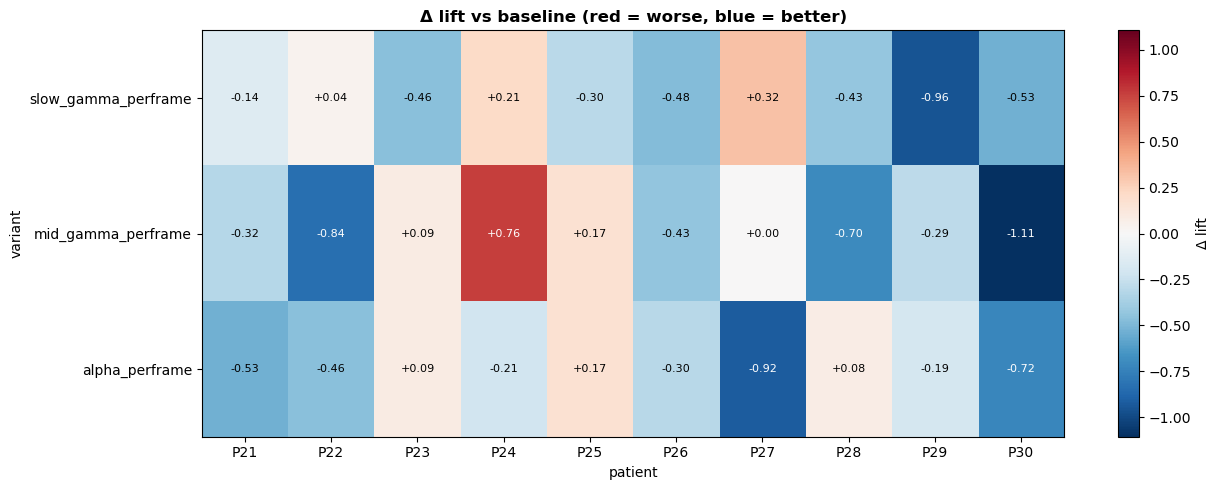


  Saved phase_sweep_20260501_1938.pkl
  Production extractHG restored.


In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Compare all variants
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*92)
print(f"  Phase-feature sweep — all variants")
print("="*92)
print(f"  {'variant':<20} {'feat_dim':>9} {'mean lift':>11} "
      f"{'Δ vs baseline':>14}")
print("-"*92)

baseline_lift = results['baseline_hg']['mean_lift']
for vname, r in results.items():
    delta = r['mean_lift'] - baseline_lift
    star = ' ★' if delta > 0.1 else ('  ✗' if delta < -0.1 else '')
    print(f"  {vname:<20} {r['feature_dim']:>9} "
          f"{r['mean_lift']:>10.2f}× {delta:>+13.2f}×{star}")
print("="*92)


# Per-patient delta heatmap
fig, ax = plt.subplots(figsize=(13, 5))
pids = sorted(results['baseline_hg']['per_patient'].keys())
variant_names = [v for v in VARIANTS.keys() if v != 'baseline_hg']

matrix = np.array([[
    results[v]['per_patient'][p]['lift'] - results['baseline_hg']['per_patient'][p]['lift']
    for p in pids] for v in variant_names])

vmax = np.max(np.abs(matrix))
im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(pids))); ax.set_xticklabels(pids)
ax.set_yticks(range(len(variant_names))); ax.set_yticklabels(variant_names)
ax.set_xlabel('patient'); ax.set_ylabel('variant')
ax.set_title('Δ lift vs baseline (red = worse, blue = better)',
             fontsize=12, fontweight='bold')
for i in range(len(variant_names)):
    for j in range(len(pids)):
        ax.text(j, i, f'{matrix[i,j]:+.2f}', ha='center', va='center',
                fontsize=8,
                color='white' if abs(matrix[i,j]) > vmax*0.5 else 'black')
plt.colorbar(im, ax=ax, label='Δ lift')
plt.tight_layout(); plt.show()


# Save
out_path = f'phase_sweep_{datetime.now().strftime("%Y%m%d_%H%M")}.pkl'
to_save = {v: {k: r[k] for k in ('mean_lift', 'lifts', 'per_patient',
                                  'feature_dim')}
           for v, r in results.items()}
with open(out_path, 'wb') as f:
    pickle.dump(to_save, f)
print(f"\n  Saved {out_path}")

# Restore production
_patch(_orig_extractHG)
print("  Production extractHG restored.")
